### Hardware-Aware Neural Architecture Search (NAS)

* The Problem: Hand-designing Neural Network Architecture requires time, and oftentimes designers produce large networks that can have high accuracy but the problem is that it might also be too computational expensive.

* The Solution:This notebook automates the discovery of such efficient Neural Architecture Networks through a NAS (Neural Architecture Search).

Effectively, this is an AI system that designs another AI. Through Evolutionary Search, the framework will automatically iterate and discover suitable architectural layers without human effort. The Multi- objective goal: The problem will be defined as the search of neural networks by optimizing accuracy for the prediction of image recognition and accuracy of parameters based on the overall number of parameters. So as, the model is optimal regarding the validation accuracy, and minimal regarding its size.

The output (Pareto Frontier):Through breed generation, and natural selection we should aim to discover the Pareto frontier of models, which represents models whose one can't do better without doing worse (more accuracy is achieved when we make it more complex), and models whose accuracy is the lowest given the amount of parameters we decide for, which represents the "best" possible accuracy when considering constraints on the resources used.

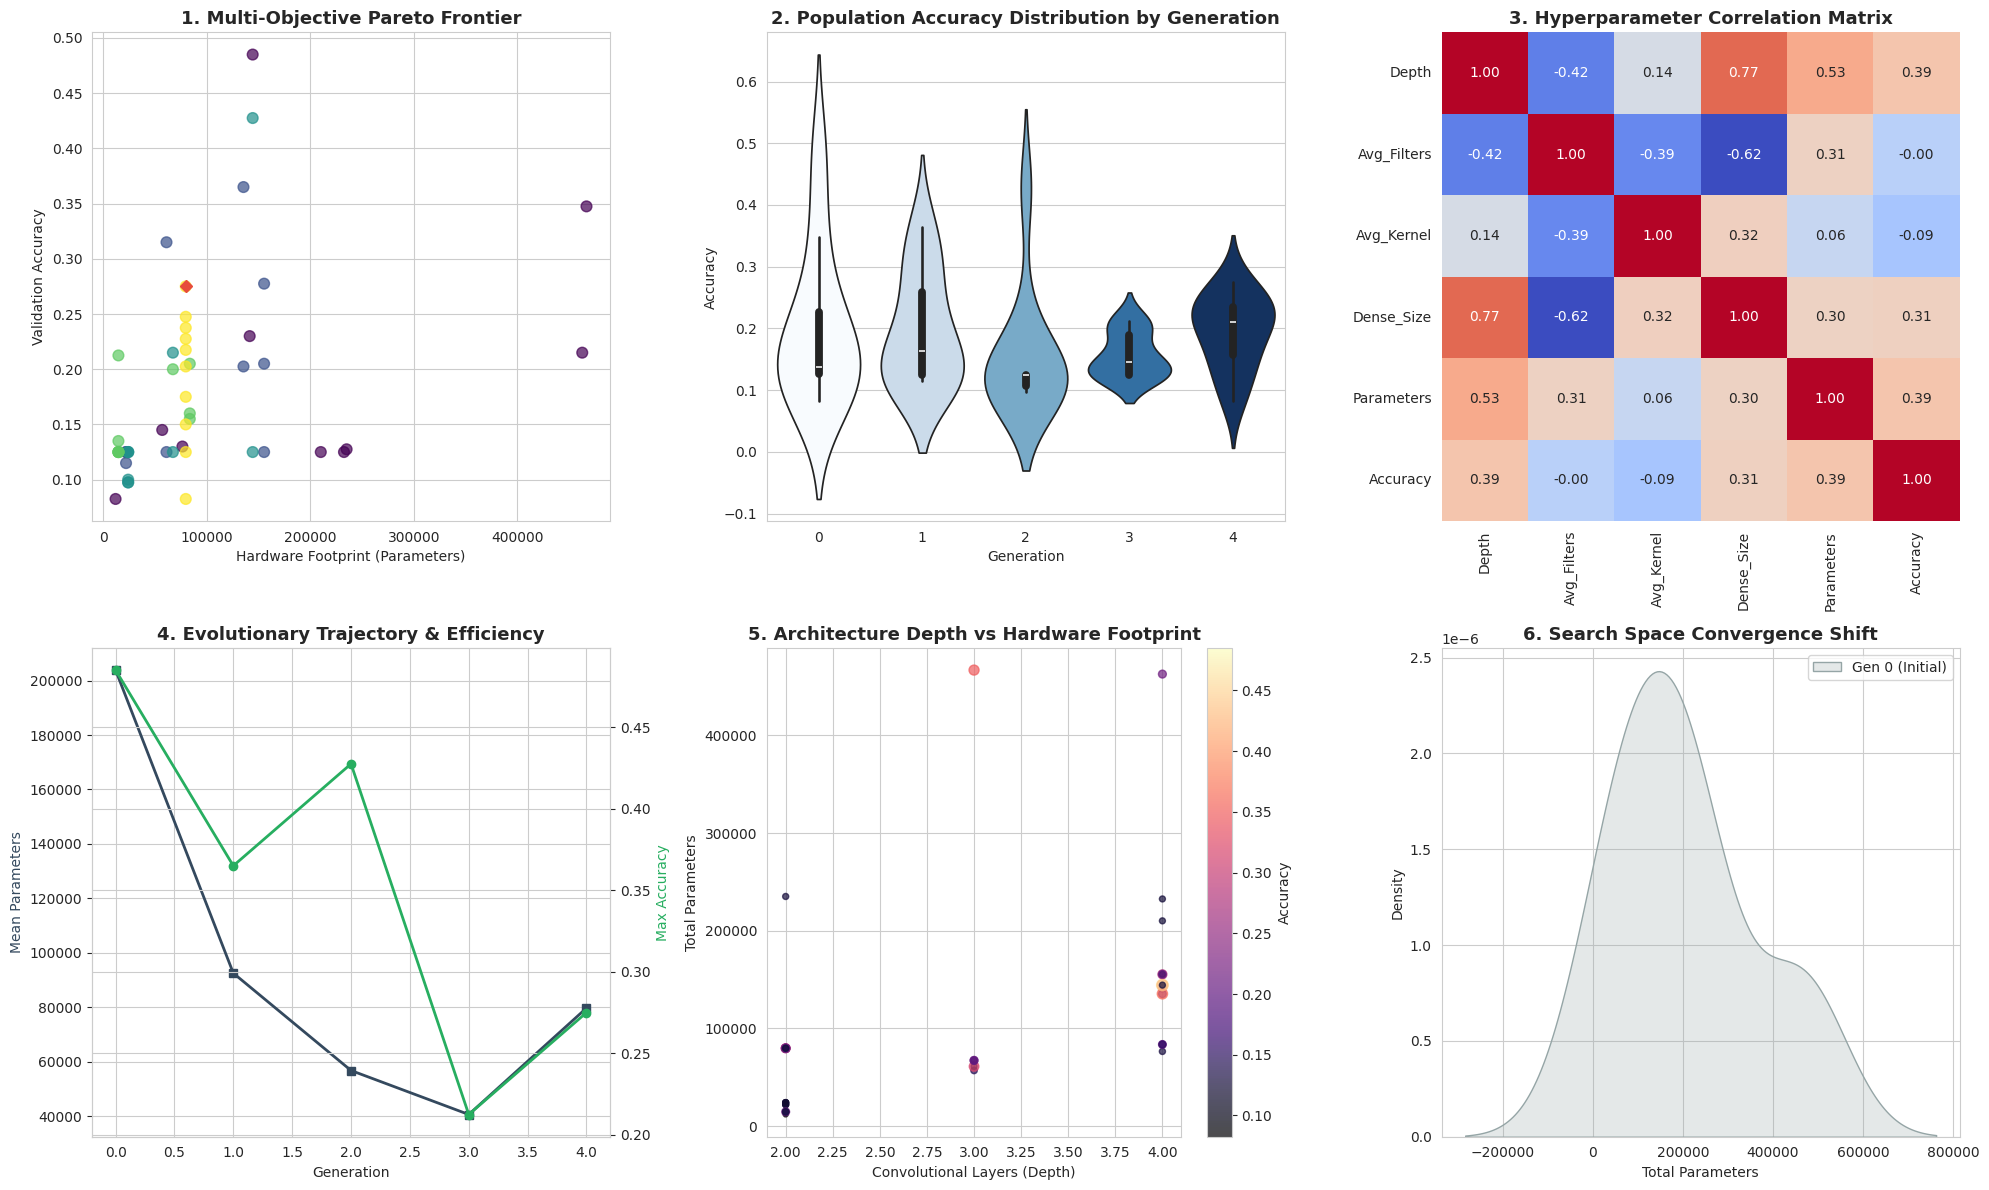

In [2]:

import os
import warnings

# Suppress all TensorFlow and Python warnings for a clean output
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.datasets import mnist
from tensorflow.keras import layers, models

tf.get_logger().setLevel('ERROR')

def load_and_prep_data(num_samples=2000):
    (x_train, y_train), (x_test, y_test) = mnist.load_data()
    x_train = np.expand_dims(x_train, -1).astype('float32') / 255.0
    x_test = np.expand_dims(x_test, -1).astype('float32') / 255.0

    indices = np.random.choice(len(x_train), num_samples, replace=False)
    x_train_sub = x_train[indices]
    y_train_sub = y_train[indices]

    return (x_train_sub, y_train_sub), (x_test, y_test)

def build_candidate_model(config, input_shape=(28, 28, 1), num_classes=10):
    inputs = tf.keras.Input(shape=input_shape)
    x = inputs

    for i in range(config['num_conv_layers']):
        filters = int(config['filters'][i])
        k_size = int(config['kernel_sizes'][i])
        kernel_tuple = (k_size, k_size)
        x = layers.Conv2D(filters, kernel_tuple, padding='same', activation='relu')(x)
        x = layers.BatchNormalization()(x)
        if config['use_pooling'][i]:
            x = layers.MaxPooling2D(2)(x)

    x = layers.GlobalAveragePooling2D()(x)

    for units in config['dense_units']:
        x = layers.Dense(int(units), activation='relu')(x)

    outputs = layers.Dense(num_classes, activation='softmax')(x)
    return models.Model(inputs, outputs)

def evaluate_architecture(config, dataset):
    (x_train, y_train), (x_val, y_val) = dataset

    tf.keras.backend.clear_session()
    model = build_candidate_model(config)

    num_params = model.count_params()

    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    history = model.fit(x_train, y_train, epochs=2, batch_size=64, verbose=0, validation_split=0.2)
    val_acc = max(history.history['val_accuracy'])

    return val_acc, num_params

def generate_random_config():
    num_conv_layers = int(np.random.randint(2, 5))
    filters = [int(np.random.choice([16, 32, 64, 128])) for _ in range(num_conv_layers)]
    kernel_sizes = [int(np.random.choice([3, 5])) for _ in range(num_conv_layers)]
    use_pooling = [bool(np.random.choice([True, False])) for _ in range(num_conv_layers)]

    num_dense_layers = int(np.random.randint(1, 3))
    dense_units = [int(np.random.choice([32, 64, 128])) for _ in range(num_dense_layers)]

    return {
        'num_conv_layers': num_conv_layers,
        'filters': filters,
        'kernel_sizes': kernel_sizes,
        'use_pooling': use_pooling,
        'dense_units': dense_units
    }

def mutate_config(config):
    new_config = config.copy()
    mutation_type = np.random.choice(['filters', 'kernel', 'dense'])

    if mutation_type == 'filters' and new_config['num_conv_layers'] > 0:
        idx = np.random.randint(0, new_config['num_conv_layers'])
        new_config['filters'][idx] = int(np.random.choice([16, 32, 64, 128]))
    elif mutation_type == 'kernel' and new_config['num_conv_layers'] > 0:
        idx = np.random.randint(0, new_config['num_conv_layers'])
        new_config['kernel_sizes'][idx] = int(np.random.choice([3, 5]))
    elif mutation_type == 'dense' and len(new_config['dense_units']) > 0:
        idx = np.random.randint(0, len(new_config['dense_units']))
        new_config['dense_units'][idx] = int(np.random.choice([32, 64, 128]))

    return new_config

def dominates(obj1, obj2):
    acc1, param1 = obj1
    acc2, param2 = obj2

    better_or_equal = (acc1 >= acc2) and (param1 <= param2)
    strictly_better = (acc1 > acc2) or (param1 < param2)

    return better_or_equal and strictly_better

def get_pareto_front(population, evaluations):
    pareto_front = []
    pareto_indices = []

    for i, eval_i in enumerate(evaluations):
        is_dominated = False
        for j, eval_j in enumerate(evaluations):
            if i != j and dominates(eval_j, eval_i):
                is_dominated = True
                break
        if not is_dominated:
            pareto_front.append(eval_i)
            pareto_indices.append(i)

    return pareto_indices

def run_evolutionary_nas():
    dataset = load_and_prep_data(num_samples=2000)

    generations = 5
    pop_size = 10

    population = [generate_random_config() for _ in range(pop_size)]
    evaluations = []

    all_data = []

    for gen in range(generations):
        current_evals = []
        for i, config in enumerate(population):
            if len(evaluations) > i and gen == 0:
                current_evals.append(evaluations[i])
                acc, params = evaluations[i]
            else:
                acc, params = evaluate_architecture(config, dataset)
                current_evals.append((acc, params))

            all_data.append({
                'Generation': gen,
                'Accuracy': acc,
                'Parameters': params,
                'Depth': config['num_conv_layers'],
                'Avg_Filters': np.mean(config['filters']),
                'Avg_Kernel': np.mean(config['kernel_sizes']),
                'Dense_Size': np.sum(config['dense_units'])
            })

        evaluations = current_evals
        pareto_indices = get_pareto_front(population, evaluations)

        parents = [population[i] for i in pareto_indices]
        parent_evals = [evaluations[i] for i in pareto_indices]

        next_population = parents.copy()
        next_evaluations = parent_evals.copy()

        while len(next_population) < pop_size:
            parent_idx = np.random.randint(0, len(parents))
            child = mutate_config(parents[parent_idx])
            next_population.append(child)

        population = next_population
        evaluations = next_evaluations

    df = pd.DataFrame(all_data)

    final_pareto_indices = get_pareto_front(population, evaluations)
    pareto_params = [evaluations[i][1] for i in final_pareto_indices]
    pareto_acc = [evaluations[i][0] for i in final_pareto_indices]

    sorted_indices = np.argsort(pareto_params)
    pareto_params = np.array(pareto_params)[sorted_indices]
    pareto_acc = np.array(pareto_acc)[sorted_indices]

    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    sns.set_style("whitegrid")

    scatter = axes[0, 0].scatter(df['Parameters'], df['Accuracy'], c=df['Generation'], cmap='viridis', alpha=0.7, s=60)
    axes[0, 0].plot(pareto_params, pareto_acc, color='#e74c3c', marker='D', linestyle='-', linewidth=2)
    axes[0, 0].set_title('1. Multi-Objective Pareto Frontier', fontsize=13, fontweight='bold')
    axes[0, 0].set_xlabel('Hardware Footprint (Parameters)')
    axes[0, 0].set_ylabel('Validation Accuracy')

    sns.violinplot(x='Generation', y='Accuracy', data=df, ax=axes[0, 1], hue='Generation', palette='Blues', legend=False)
    axes[0, 1].set_title('2. Population Accuracy Distribution by Generation', fontsize=13, fontweight='bold')

    corr_vars = ['Depth', 'Avg_Filters', 'Avg_Kernel', 'Dense_Size', 'Parameters', 'Accuracy']
    sns.heatmap(df[corr_vars].corr(), annot=True, cmap='coolwarm', fmt=".2f", ax=axes[0, 2], cbar=False)
    axes[0, 2].set_title('3. Hyperparameter Correlation Matrix', fontsize=13, fontweight='bold')

    ax_twin = axes[1, 0].twinx()
    gen_groups = df.groupby('Generation')
    axes[1, 0].plot(gen_groups['Parameters'].mean(), color='#34495e', marker='s', linewidth=2, label='Mean Parameters')
    ax_twin.plot(gen_groups['Accuracy'].max(), color='#27ae60', marker='o', linewidth=2, label='Max Accuracy')
    axes[1, 0].set_title('4. Evolutionary Trajectory & Efficiency', fontsize=13, fontweight='bold')
    axes[1, 0].set_xlabel('Generation')
    axes[1, 0].set_ylabel('Mean Parameters', color='#34495e')
    ax_twin.set_ylabel('Max Accuracy', color='#27ae60')

    scatter_depth = axes[1, 1].scatter(df['Depth'], df['Parameters'], c=df['Accuracy'], cmap='magma', s=df['Accuracy']*150, alpha=0.7)
    axes[1, 1].set_title('5. Architecture Depth vs Hardware Footprint', fontsize=13, fontweight='bold')
    axes[1, 1].set_xlabel('Convolutional Layers (Depth)')
    axes[1, 1].set_ylabel('Total Parameters')
    plt.colorbar(scatter_depth, ax=axes[1, 1], label='Accuracy')

    sns.kdeplot(data=df[df['Generation'] == 0], x='Parameters', fill=True, label='Gen 0 (Initial)', ax=axes[1, 2], color='#95a5a6', warn_singular=False)
    sns.kdeplot(data=df[df['Generation'] == df['Generation'].max()], x='Parameters', fill=True, label='Final Gen', ax=axes[1, 2], color='#8e44ad', warn_singular=False)
    axes[1, 2].set_title('6. Search Space Convergence Shift', fontsize=13, fontweight='bold')
    axes[1, 2].set_xlabel('Total Parameters')
    axes[1, 2].legend()

    plt.tight_layout()
    plt.show()

if __name__ == '__main__':
    run_evolutionary_nas()